# SVM Notebook

Presentation notebook for the Support Vector Machine workflow.

This notebook keeps the workflow lightweight while documenting the final analysis, visuals, and presentation notes.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def find_ml_root(start=None):
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        for data_root in [candidate, candidate / "ml"]:
            if (data_root / "data" / "processed" / "cleaned_dataset.csv").exists():
                return data_root
    raise FileNotFoundError("Could not locate ml/data/processed/cleaned_dataset.csv")

ML_DIR = find_ml_root()
ROOT_DIR = ML_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from svm_threshold import ThresholdedClassifier
DATA_PATH = ML_DIR / "data" / "processed" / "cleaned_dataset.csv"
MODEL_PATH = ML_DIR / "models" / "import_risk_svm.joblib"
METRICS_PATH = ML_DIR / "models" / "svm_metrics.json"
METRICS_PATH = ML_DIR / "models" / "svm_metrics.json"
FEATURE_COLUMNS = [
    "price_usd",
    "weight_kg",
    "length_m",
    "width_m",
    "height_m",
    "volume_m3",
    "max_dimension_m",
    "dimension_sum_m",
    "density_kg_m3",
    "value_per_kg",
    "value_per_m3",
]
TARGET_COLUMN = "risk"
RANDOM_STATE = 42
MAX_ROWS_FOR_SVM = 80000


In [2]:
df = pd.read_csv(DATA_PATH)
df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()

print(df.shape)
display(df.head())
display(df[TARGET_COLUMN].value_counts())

(263821, 12)
   price_usd  weight_kg  length_m  width_m  height_m  volume_m3  max_dimension_m  dimension_sum_m  density_kg_m3  value_per_kg  value_per_m3       risk
0      37.66       1.10      0.40     0.39      0.26     0.0406             0.40             1.05        27.1203       34.2364      927.5862   LOW RISK
1     144.65       0.39      0.11     0.06      0.03     0.0002             0.11             0.20      1969.6970      370.8974   723250.0000  HIGH RISK
2      38.57       0.97      0.79     0.55      0.35     0.1521             0.79             1.69         6.3784       39.7629      253.5832   LOW RISK
3      10.34       6.22      0.36     0.37      0.02     0.0027             0.37             0.75      2334.8348        1.6624     3829.6296   LOW RISK
4      21.63       1.18     17.77     0.27      0.13     0.6237            17.77            18.17         1.8919       18.3305       34.6801   LOW RISK
risk
LOW RISK     224247
HIGH RISK     39574


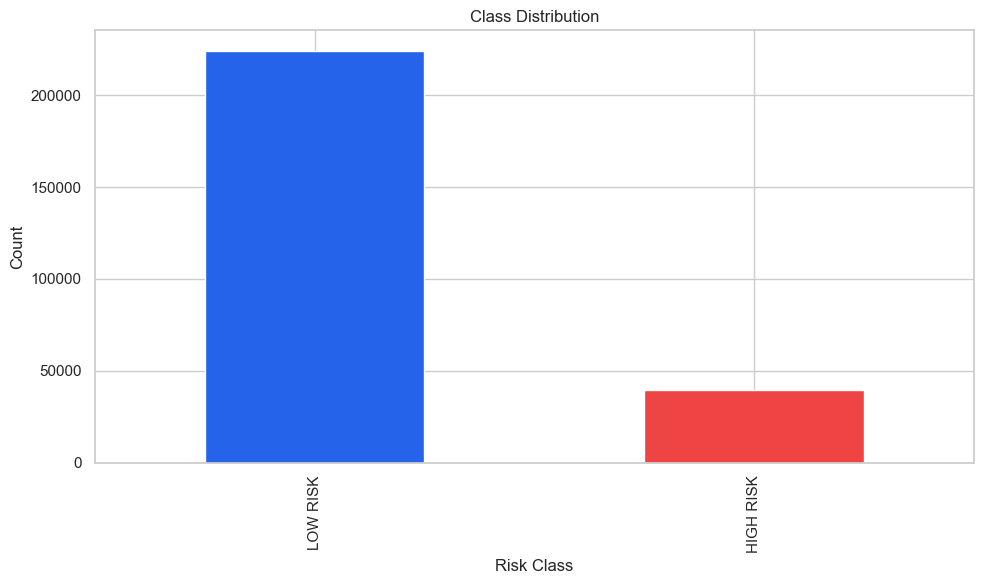

In [3]:
class_counts = df[TARGET_COLUMN].value_counts()

ax = class_counts.plot(kind="bar", color=["#2563eb", "#ef4444"])
ax.set_title("Class Distribution")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
sample_df, _ = train_test_split(
    df,
    train_size=min(len(df), MAX_ROWS_FOR_SVM),
    random_state=RANDOM_STATE,
    stratify=df[TARGET_COLUMN],
)

X = sample_df[FEATURE_COLUMNS]
y = sample_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

best_model = joblib.load(MODEL_PATH)
y_pred = best_model.predict(X_test)
predicted_labels = pd.Series(y_pred).map({0: "LOW RISK", 1: "HIGH RISK"})
decision_scores = best_model.decision_function(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, predicted_labels),
    "precision": precision_score(y_test, predicted_labels, pos_label="HIGH RISK", zero_division=0),
    "recall": recall_score(y_test, predicted_labels, pos_label="HIGH RISK", zero_division=0),
    "f1": f1_score(y_test, predicted_labels, pos_label="HIGH RISK", zero_division=0),
}

print("Loaded model:", MODEL_PATH.name)
print(metrics)
print(classification_report(y_test, predicted_labels, zero_division=0))


Loaded model: import_risk_svm.joblib
{'accuracy': 0.846875, 'precision': 0.48801534036433364, 'recall': 0.4241666666666667, 'f1': 0.4538564422648239}
              precision    recall  f1-score   support

   HIGH RISK       0.49      0.42      0.45      2400
    LOW RISK       0.90      0.92      0.91     13600

    accuracy                           0.85     16000
   macro avg       0.69      0.67      0.68     16000
weighted avg       0.84      0.85      0.84     16000



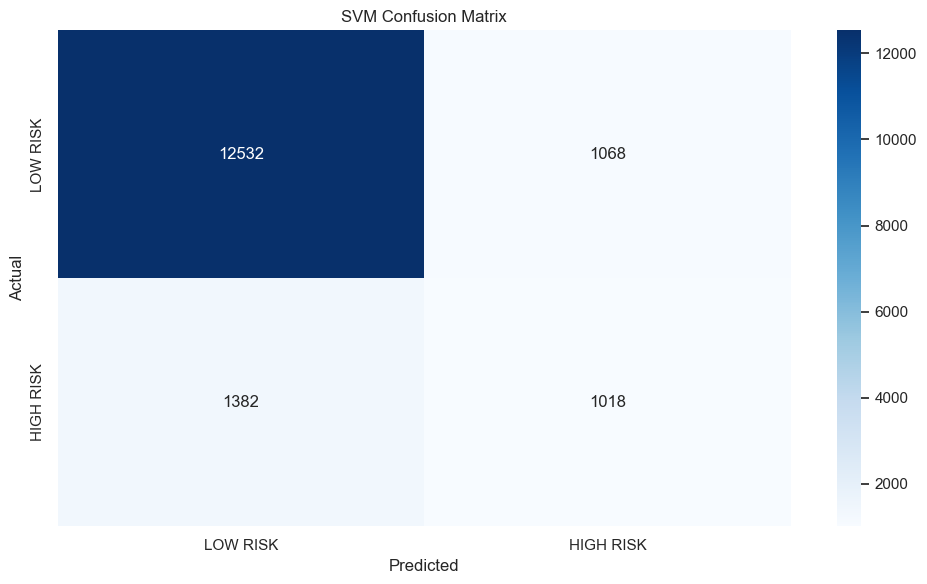

In [5]:
cm = confusion_matrix(y_test, predicted_labels, labels=["LOW RISK", "HIGH RISK"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["LOW RISK", "HIGH RISK"],
    yticklabels=["LOW RISK", "HIGH RISK"],
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


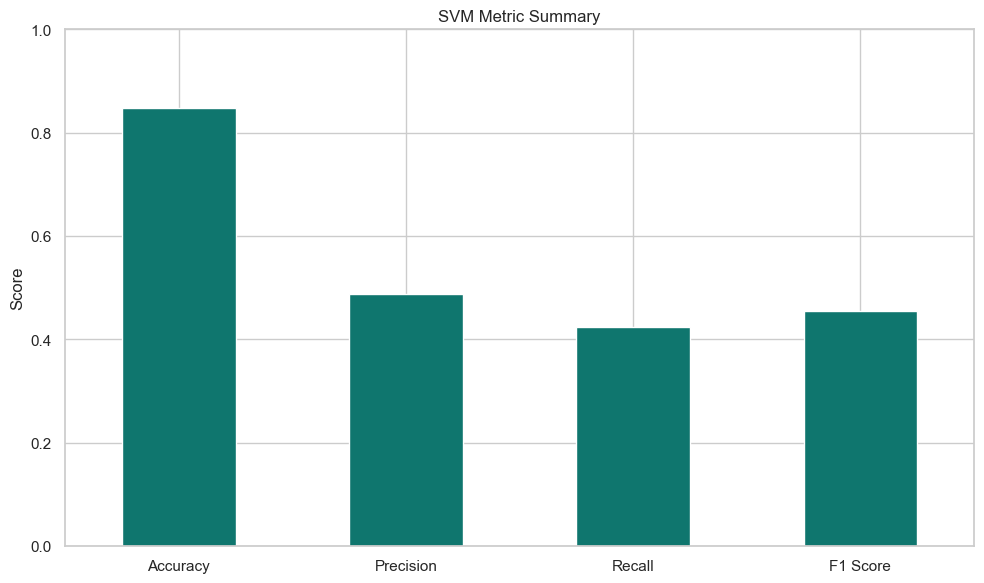

In [6]:
metric_series = pd.Series({
    "Accuracy": metrics["accuracy"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "F1 Score": metrics["f1"],
})

ax = metric_series.plot(kind="bar", color="#0f766e")
ax.set_ylim(0, 1)
ax.set_title("SVM Metric Summary")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

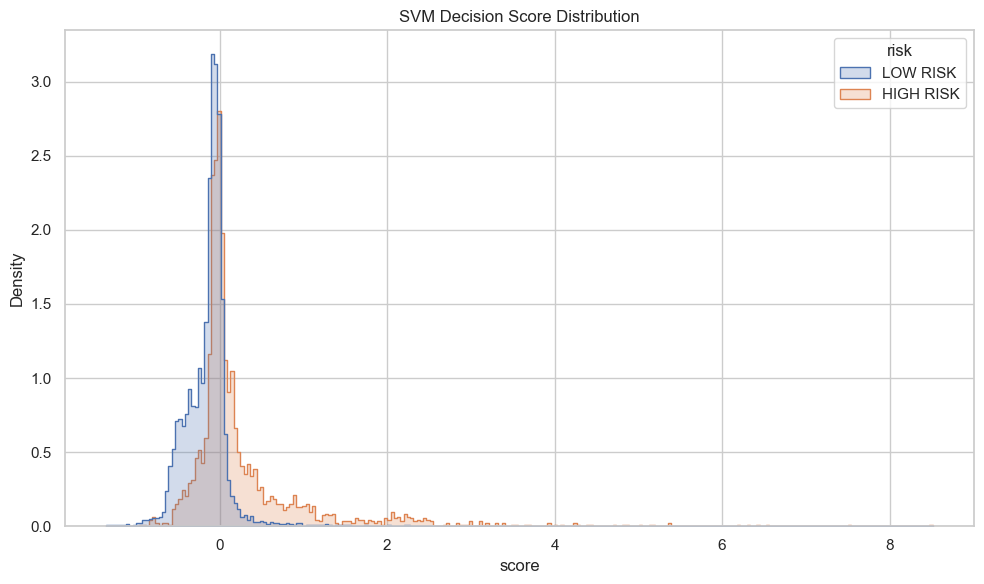

In [7]:
decision_scores = best_model.decision_function(X_test)
score_frame = pd.DataFrame({"score": decision_scores, "risk": y_test.values})

sns.histplot(data=score_frame, x="score", hue="risk", element="step", stat="density", common_norm=False)
plt.title("SVM Decision Score Distribution")
plt.tight_layout()
plt.show()